In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ==============================================================================
# Step 1: Import Libraries and Data Preparation
# ==============================================================================
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the pre-processed dataset
df = pd.read_csv('/content/drive/MyDrive/diabetes_data_pre_processed.csv')

# --- Define Features (X) and Target (y) ---
# Using all standardized ('_std') and encoded features:
X = df[[
    'gender', 'hypertension', 'heart_disease', 'smoking_history',
    'age_std', 'bmi_std', 'HbA1c_level_std', 'blood_glucose_level_std',
    'age_group_Adult', 'age_group_Middle-aged', 'age_group_Senior', 'age_group_Young'
]]
y = df['diabetes']

# --- Validation Method: Train-Test Split (70% Train, 30% Test, Stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Data preparation and Train-Test Split complete.")

Data preparation and Train-Test Split complete.


In [7]:
# ==============================================================================
# Step 2: Model 1 - Baseline KNN (k=5)
# ==============================================================================
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train)
y_pred_baseline = knn_baseline.predict(X_test)
y_prob_baseline = knn_baseline.predict_proba(X_test)[:, 1]

# Calculate Evaluation Metrics for the Baseline Model
acc_b = accuracy_score(y_test, y_pred_baseline)
prec_b = precision_score(y_test, y_pred_baseline)
recall_b = recall_score(y_test, y_pred_baseline)
f1_b = f1_score(y_test, y_pred_baseline)
auc_roc_b = roc_auc_score(y_test, y_prob_baseline)

print(f"\nBaseline KNN (k=5) F1 Score: {f1_b:.4f}")


Baseline KNN (k=5) F1 Score: 0.9608


In [8]:
# ==============================================================================
# Step 3: Parameter Tuning (GridSearchCV)
# ==============================================================================
# Define the range of k values (n_neighbors) to test
param_grid = {'n_neighbors': np.arange(1, 31)} # Testing k from 1 to 30

# Use Stratified K-Fold for robust cross-validation on the training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV: Optimize for F1 Score
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='f1',           # Optimization Metric
    cv=cv,
    n_jobs=-1
)

# Execute the search on the training data
grid_search.fit(X_train, y_train)

best_k = grid_search.best_params_['n_neighbors']
best_knn_model = grid_search.best_estimator_

print(f"\nOptimal number of neighbors (k) found by GridSearchCV: {best_k}")


Optimal number of neighbors (k) found by GridSearchCV: 1


In [9]:
# ==============================================================================
# Step 4: Model 2 - Tuned KNN Evaluation
# ==============================================================================
# Predict using the best tuned model on the Test Set
y_pred_tuned = best_knn_model.predict(X_test)
y_prob_tuned = best_knn_model.predict_proba(X_test)[:, 1]

# Calculate Evaluation Metrics for the Tuned Model
acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
recall_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)
auc_roc_t = roc_auc_score(y_test, y_prob_tuned)
conf_matrix = confusion_matrix(y_test, y_pred_tuned)

# Presentation of Tuned Model Results (Table)
print("\n=== Tuned KNN Model Metrics (Test Set) ===")
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1 Score', 'AUC-ROC'],
    'Value': [acc_t, prec_t, recall_t, f1_t, auc_roc_t]
})
print(results_df.to_string(index=False, float_format="%.4f"))

# Visualization of the Confusion Matrix (Image for report)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted 0 (No Diab.)', 'Predicted 1 (Diab.)'],
            yticklabels=['Actual 0 (No Diab.)', 'Actual 1 (Diab.)'])
plt.title(f'Confusion Matrix for Tuned KNN (k={best_k})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('knn_confusion_matrix.png')
plt.close() # Saves the image file.


=== Tuned KNN Model Metrics (Test Set) ===
              Metric  Value
            Accuracy 0.9828
           Precision 0.9680
Recall (Sensitivity) 0.9986
            F1 Score 0.9831
             AUC-ROC 0.9828



=== Model Comparison Summary ===
            Model Variety  k Value  Accuracy  Precision  Recall  F1 Score
             Baseline KNN        5    0.9592     0.9248  0.9998    0.9608
GridSearch Best KNN (k=1)        1    0.9828     0.9680  0.9986    0.9831


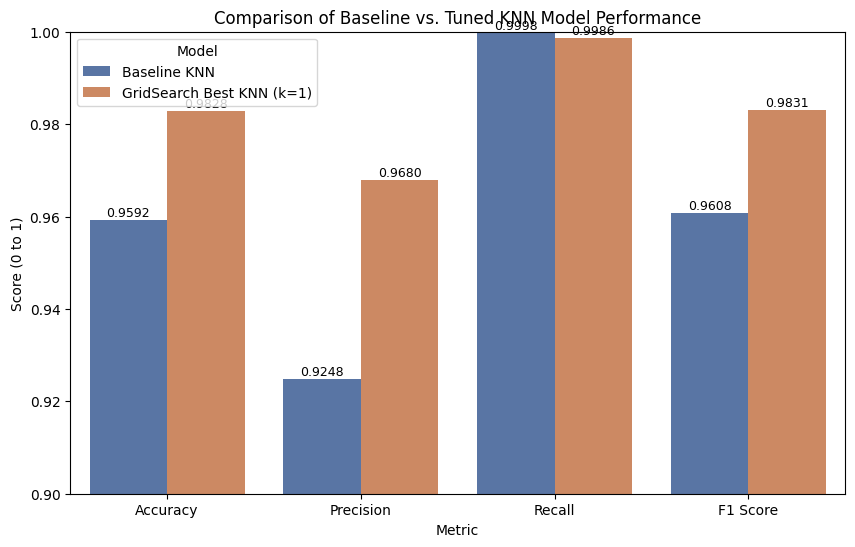


Model Comparison Bar Chart saved to 'knn_model_comparison_barplot.png'.


In [11]:
# ==============================================================================
# Step 5.1: Model Comparison Summary (Table)
# ==============================================================================
comparison_data = {
    'Model Variety': ['Baseline KNN', f'GridSearch Best KNN (k={best_k})'],
    'k Value': [5, best_k],
    'Accuracy': [acc_b, acc_t],
    'Precision': [prec_b, prec_t],
    'Recall': [recall_b, recall_t],
    'F1 Score': [f1_b, f1_t]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n=== Model Comparison Summary ===")
print(comparison_df.to_string(index=False, float_format="%.4f"))

# ==============================================================================
# Step 5.2: Visualization of Model Comparison (Bar Chart) 📊
# ==============================================================================

# Melt the DataFrame to long format for easier plotting with seaborn
plot_df = comparison_df.drop(columns=['k Value']).melt(
    id_vars='Model Variety', var_name='Metric', value_name='Score'
)

# Filter to show only the four main classification metrics
plot_df = plot_df[plot_df['Metric'].isin(['Accuracy', 'Precision', 'Recall', 'F1 Score'])]

plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    data=plot_df, x='Metric', y='Score', hue='Model Variety', palette='deep'
)
plt.ylim(0.9, 1.0) # Set Y-axis limit for better visual distinction
plt.title('Comparison of Baseline vs. Tuned KNN Model Performance')
plt.ylabel('Score (0 to 1)')
plt.legend(title='Model')

# Add score labels on top of the bars
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.4f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   fontsize=9, color='black',
                   xytext=(0, 5),
                   textcoords='offset points')

plt.savefig('knn_model_comparison_barplot.png')
plt.show() #

print("\nModel Comparison Bar Chart saved to 'knn_model_comparison_barplot.png'.")